# Segmenter les clients à l'aide de K-Means

In [1]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import seaborn as sb
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv("../data/preprocessed_data.csv")
data

,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Contract,Churn,tenure,MonthlyCharges,TotalCharges
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,1,0,0,0.013889,0.115423,0.003437
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,1,0,0,0,0,1,0,0.472222,0.385075,0.217564
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,0,0,0,0,1,0,1,0.027778,0.354229,0.012453
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,...,1,1,0,0,0,1,0,0.625000,0.239303,0.211951
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,...,0,0,0,0,1,0,1,0.027778,0.521891,0.017462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,...,1,1,1,1,1,1,0,0.333333,0.662189,0.229194
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1,...,1,0,1,1,1,1,0,1.000000,0.845274,0.847792
7040,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,1,0,0,0.152778,0.112935,0.039892
7041,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,...,0,0,0,0,1,0,1,0.055556,0.558706,0.035303


In [3]:
X = data.drop("Churn", axis=1)
y = data.Churn

X

,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Contract,tenure,MonthlyCharges,TotalCharges
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,1,0,0,0,0,1,0,0.013889,0.115423,0.003437
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,0,1,0,0,0,0,1,0.472222,0.385075,0.217564
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,1,0,0,0,0,1,0,0.027778,0.354229,0.012453
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,...,0,1,1,0,0,0,1,0.625000,0.239303,0.211951
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,...,0,0,0,0,0,1,0,0.027778,0.521891,0.017462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,...,0,1,1,1,1,1,1,0.333333,0.662189,0.229194
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1,...,1,1,0,1,1,1,1,1.000000,0.845274,0.847792
7040,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,0,1,0,0.152778,0.112935,0.039892
7041,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,...,0,0,0,0,0,1,0,0.055556,0.558706,0.035303


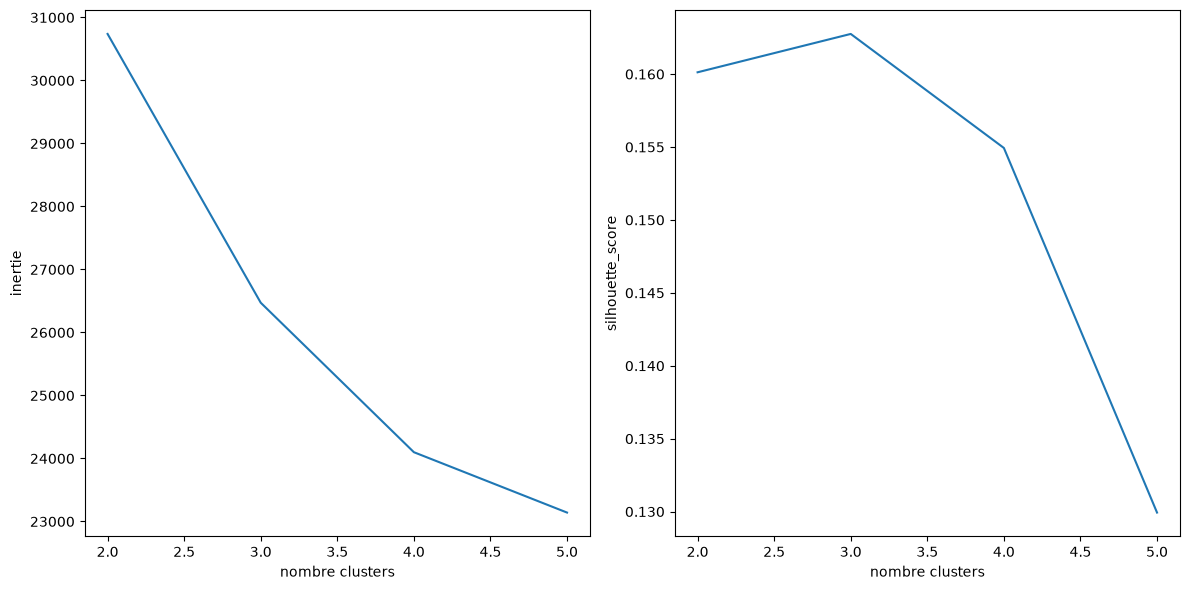

In [ ]:
# Elbow + Silhouette
inerties = []
silhouette_scores = []

for i in range(2, 6):
    kmeans_model = KMeans(
        n_clusters=i,
        random_state=11
    )
    predicted_y = kmeans_model.fit_predict(X)

    inerties.append(kmeans_model.inertia_)
    silhouette_scores.append(silhouette_score(X, predicted_y))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(range(2, 6), inerties)
axs[0].set_xlabel('nombre clusters')
axs[0].set_ylabel('inertie')

axs[1].plot(range(2, 6), silhouette_scores)
axs[1].set_xlabel('nombre clusters')
axs[1].set_ylabel('silhouette_score')

plt.tight_layout()
plt.show()

selon le plot de la méthode Elbow le nombre de k idéal est soit 3 soit 4 mais en se basant sur le silhouette score on remarque que 3 et mieux que 4.

In [5]:
kmeans_model = KMeans(
        n_clusters=3,
        random_state=11
    )
kmeans_predicted_y = kmeans_model.fit_predict(X)

### min_samples
**Description** : Nombre minimum de points dans le voisinage eps pour qu’un point soit considéré comme point cœur.
<br>
**Règle pratique** : une valeur courante est min_samples ≥ D + 1 où D est la dimensionalité des données. Pour des données 2D, min_samples = 5 est un bon point de départ. Pour des données bruitées, augmentez cette valeur.

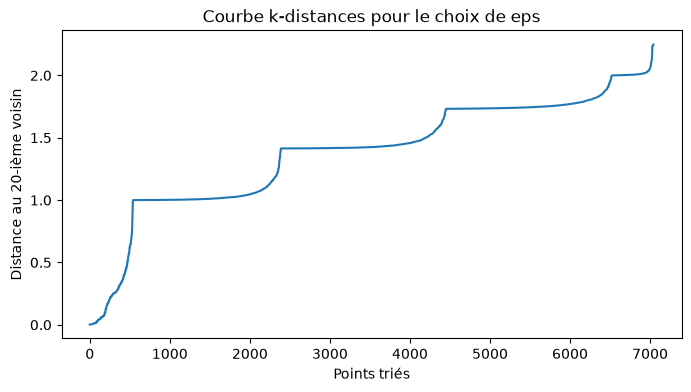

In [6]:
# Courbe k-distances pour choisir eps
k = 20
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)
distances, indices = nn.kneighbors(X)

# Trier les distances au k-ième voisin
distances_k = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 4))
plt.plot(distances_k)
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {k}-ième voisin')
plt.title('Courbe k-distances pour le choix de eps')
plt.show()

In [15]:
# DBSCAN
df = pd.DataFrame([], columns=["nb_clusters", "eps", "outliers", "divisions"])
eps_range = np.arange(0.01, 2.5, 0.01)

for i, ep in enumerate(eps_range):
    dbscan = DBSCAN(eps=ep, min_samples=k)
    dbscan_labels = dbscan.fit_predict(X)
    df.loc[i] = [
        len(set(dbscan_labels))-( 1 if (-1 in dbscan_labels) else 0), 
        ep,
        list(dbscan_labels).count(-1),
        np.unique(
            dbscan_labels[dbscan_labels != -1], 
            return_counts=True
        )[1]
    ]

df

,nb_clusters,eps,outliers,divisions
0,2,0.01,6979,"[40, 24]"
1,2,0.02,6952,"[52, 39]"
2,3,0.03,6912,"[63, 47, 21]"
3,3,0.04,6912,"[63, 47, 21]"
4,5,0.05,6860,"[64, 54, 24, 20, 21]"
...,...,...,...,...
245,1,2.46,0,[7043]
246,1,2.47,0,[7043]
247,1,2.48,0,[7043]
248,1,2.49,0,[7043]


In [20]:
df_filtered = df[
    df["divisions"].map(lambda x: all(v >= 20 for v in x))
]

df_filtered

,nb_clusters,eps,outliers,divisions
0,2,0.01,6979,"[40, 24]"
1,2,0.02,6952,"[52, 39]"
2,3,0.03,6912,"[63, 47, 21]"
3,3,0.04,6912,"[63, 47, 21]"
4,5,0.05,6860,"[64, 54, 24, 20, 21]"
...,...,...,...,...
245,1,2.46,0,[7043]
246,1,2.47,0,[7043]
247,1,2.48,0,[7043]
248,1,2.49,0,[7043]


In [23]:
df_filtered.select_dtypes("number")\
    .groupby(by="nb_clusters")\
    .aggregate("min")\
    .sort_values('outliers', ascending=True)

,eps,outliers
nb_clusters,,
1,1.44,0
2,0.01,930
4,1.42,1831
13,0.26,3978
12,0.24,4036
11,0.21,4106
17,0.56,6500
16,0.36,6520
15,0.34,6554


In [ ]:
df[
    ((df["nb_clusters"]==2) & (df["outliers"]==930)) 
    | ((df["nb_clusters"]==4) & (df["outliers"]==1831))
]

,nb_clusters,eps,outliers,divisions
142,4,1.43,1831,"[961, 2452, 1524, 275]"
172,2,1.73,930,"[6091, 22]"


le moins nombre d'outliers est repéré à la ligne 172 où on a 2 clusters avec un eps égale à 1.73 et 930 comme valeurs aberrantes. Cependant, à cause de la mauvaise distribution du data en va pas s'en interesser. On va choisir plutôt la ligne 142 parceque c'est le résultat le plus intéressant des deux.
<br>
**Pourquoi ?**
<br>
* On obtient 4 clusters, donc une segmentation assez détaillée.
* Les clusters ont des tailles relativement variées mais pas complètement déséquilibrées.
* Le plus petit cluster contient 275 clients, ce qui reste significatif.<br>
En revanche, 26 % des observations sont considérées comme noise (-1), ce qui est assez élevé.
<br>

In [25]:
dbscan = DBSCAN(eps=1.43, min_samples=k)
dbscan_predicted_y = dbscan.fit_predict(X)

**les méthodes de liaison de distance euclidienne les plus courantes**<br>
Parmi les autres indicateurs de distance qui peuvent être utilisées, citons les distances de Minkowski, Hamming, Mahalanobis, Hausdorf et Manhattan. Notez que chaque méthode de liaison génère différents clusters à partir du même jeu de données. Le choix de la méthode de partitionnement par liaison appropriée dépend de facteurs tels que le type de données partitionnée, la densité de données, la forme des clusters et la présence de valeurs aberrantes ou de bruit dans le jeu de données.

In [27]:
# Agglomerative Clustering

agg = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

agg_predicted_y = agg.fit_predict(X)

In [32]:
# Silhouette Score, Davies-Bouldin, Calinski-Harabasz
print(f"""
************************************************************
* metric/algo       *   KMeans   *   DBSCAN   *    AGCL    *
************************************************************
* Silhouette score  * {silhouette_score(X, kmeans_predicted_y):=10.2f} * {silhouette_score(X, dbscan_predicted_y):=10.2f} * {silhouette_score(X, agg_predicted_y):=10.2f} *
************************************************************
* Davies-Bouldin    * {davies_bouldin_score(X, kmeans_predicted_y):=10.2f} * {davies_bouldin_score(X, dbscan_predicted_y):=10.2f} * {davies_bouldin_score(X, agg_predicted_y):=10.2f} *
************************************************************
* Calinski-Harabasz * {calinski_harabasz_score(X, kmeans_predicted_y):=10.2f} * {calinski_harabasz_score(X, dbscan_predicted_y):=10.2f} * {calinski_harabasz_score(X, agg_predicted_y):=10.2f} *
************************************************************
""")


************************************************************
* metric/algo       *   KMeans   *   DBSCAN   *    AGCL    *
************************************************************
* Silhouette score  *       0.16 *       0.09 *       0.12 *
************************************************************
* Davies-Bouldin    *       1.94 *       2.55 *       1.98 *
************************************************************
* Calinski-Harabasz *    1261.06 *     663.61 *    1002.18 *
************************************************************



Selon ces métriques le modèle le plus performant est kmeans

In [6]:
original_data = pd.read_csv("../data/cleaned_data.csv")
original_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,False,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,False,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,False,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,False,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,False,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [7]:
original_data["cluster"] = kmeans_predicted_y

numerical_data_describe = original_data.groupby(by="cluster").describe()
categorical_data_describe = original_data.groupby(by="cluster").describe(include="str")

In [8]:
numerical_data_describe.T

cluster                         0            1            2
tenure         count  1957.000000  1586.000000  3500.000000
               mean     56.042412    30.686003    19.899143
               std      16.302005    24.074223    18.235867
               min       0.000000     0.000000     1.000000
               25%      47.000000     8.000000     4.000000
               50%      61.000000    25.000000    14.000000
               75%      70.000000    52.000000    31.000000
               max      72.000000    72.000000    72.000000
MonthlyCharges count  1957.000000  1586.000000  3500.000000
               mean     83.996832    22.232251    73.278414
               std      20.969224     5.986331    21.466714
               min      29.800000    18.250000    19.400000
               25%      67.450000    19.700000    55.200000
               50%      85.000000    20.200000    75.800000
               75%     103.250000    23.900000    90.150000
               max     118.750000    70.350000   117.450000
TotalCharges   count  1957.000000  1586.000000  3500.000000
               mean   4814.784440   698.138588  1578.967929
               std    1999.679864   586.575488  1652.489495
               min       0.000000     0.000000    19.450000
               25%    3330.100000   166.287500   258.950000
               50%    4889.300000   557.100000   990.575000
               75%    6383.900000  1152.350000  2397.037500
               max    8684.800000  3533.600000  7713.550000

In [9]:
categorical_data_describe.T

cluster                                        0                    1  \
gender           count                      1957                 1586   
                 unique                        2                    2   
                 top                      Female                 Male   
                 freq                        981                  806   
Partner          count                      1957                 1586   
                 unique                        2                    2   
                 top                         Yes                   No   
                 freq                       1366                  810   
Dependents       count                      1957                 1586   
                 unique                        2                    2   
                 top                          No                   No   
                 freq                       1166                  913   
PhoneService     count                      1957                 1586   
                 unique                        2                    2   
                 top                         Yes                  Yes   
                 freq                       1694                 1557   
MultipleLines    count                      1957                 1586   
                 unique                        3                    3   
                 top                         Yes                   No   
                 freq                       1146                 1214   
InternetService  count                      1957                 1586   
                 unique                        2                    3   
                 top                         DSL                   No   
                 freq                       1074                 1507   
OnlineSecurity   count                      1957                 1586   
                 unique                        2                    3   
                 top                         Yes  No internet service   
                 freq                       1255                 1507   
OnlineBackup     count                      1957                 1586   
                 unique                        2                    3   
                 top                         Yes  No internet service   
                 freq                       1319                 1507   
DeviceProtection count                      1957                 1586   
                 unique                        2                    3   
                 top                         Yes  No internet service   
                 freq                       1417                 1507   
TechSupport      count                      1957                 1586   
                 unique                        2                    3   
                 top                         Yes  No internet service   
                 freq                       1326                 1507   
StreamingTV      count                      1957                 1586   
                 unique                        2                    3   
                 top                         Yes  No internet service   
                 freq                       1352                 1507   
StreamingMovies  count                      1957                 1586   
                 unique                        2                    3   
                 top                         Yes  No internet service   
                 freq                       1371                 1507   
Contract         count                      1957                 1586   
                 unique                        3                    3   
                 top                    Two year             Two year   
                 freq                       1048                  647   
PaperlessBilling count                      1957                 1586   
                 unique                        2          

1. Cluster 0 : Les Clients Fidèles VIP & Multi-Services (1 957 clients - ~27.8 %)<br>
* **Ancienneté élevée** : Moyenne de 56 mois (~4.6 ans), médiane à 61 mois.
* **Dépenses fortes** : Facture mensuelle moyenne de 84,00 $ et total accumulé très élevé (4 814.78 $).
* **Profil de services** : Fortement équipés en services additionnels (DSL prédominant, ligne téléphonique, sécurité en ligne, sauvegarde, support technique, streaming).
* **Engagement contractuel** : Principalement sous contrat de 2 ans (Two year), réglant majoritairement par carte de crédit automatique.

```text
**Interprétation** : Ce sont les clients les plus rentables et les plus fidèles. Leur fort niveau d'équipement et d'engagement contractuel en fait une population très stable à préserver.
```
---
2. Cluster 1 : Les Clients Téléphonie Pure / Basiques (1 586 clients - ~22.5 %)<br>
* **Ancienneté modérée** : Moyenne de 30.7 mois (~2.5 ans).
* **Dépenses très faibles** : Facture mensuelle moyenne de seulement 22.23 $ et total accumulé bas (698.14 $).
* **Profil de services** : Pratiquement aucun service Internet (1 507 clients sans Internet), ils utilisent principalement le service téléphonique de base (PhoneService Oui).
* **Engagement contractuel** : Forte représentation des contrats long terme (2 ans) et paiement prédominant par chèque postal (Mailed check).

```text
Interprétation : Une clientèle à faible valeur financière unitaire mais très peu coûteuse à maintenir et très stable.
```
---
3. Cluster 2 : Les Clients Récents & Volatiles sur Fibre (3 500 clients - ~49.7 %)<br>
* **Ancienneté faible** : Moyenne de 19.9 mois, avec 50 % des clients présents depuis moins de 14 mois.
* **Dépenses mensuelles élevées** : Facture mensuelle moyenne de 73.28 $ due à l'abonnement Fibre Optique (Fiber optic).
* **Profil de services** : Connectés en Fibre Optique, mais manquent souvent d'options de protection/support (OnlineSecurity, TechSupport sont majoritairement "No").
* **Engagement contractuel** : Quasi-totalité sous contrat mois par mois (Month-to-month, 3 341 clients), avec un mode de paiement par chèque électronique (Electronic check).

```text
Interprétation : C'est le groupe le plus à risque (segment Churn critique). Ils paient cher dès le début sans engagement à long terme et sans support technique, ce qui favorise les résiliations précoces.
```

In [12]:
original_data["cluster"] = original_data["cluster"].map(
    {
        0: "Clients Fidèles VIP & Multi-Services", 
        1: "Clients Téléphonie Pure / Basiques", 
        2: "Clients Récents & Volatiles sur Fibre"
    }
)
original_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,cluster
0,Female,False,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Clients Récents & Volatiles sur Fibre
1,Male,False,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,Clients Téléphonie Pure / Basiques
2,Male,False,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Clients Récents & Volatiles sur Fibre
3,Male,False,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Clients Fidèles VIP & Multi-Services
4,Female,False,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Clients Récents & Volatiles sur Fibre


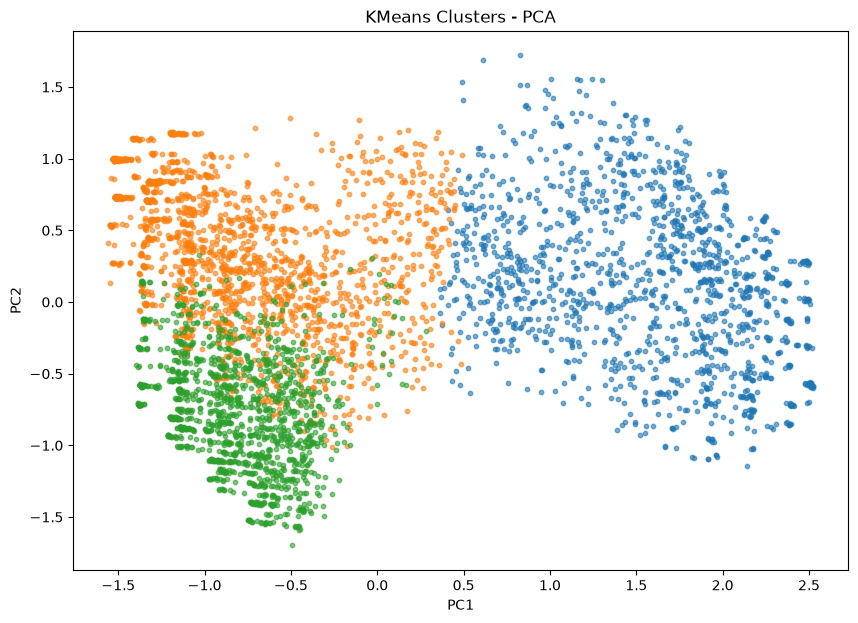

In [ ]:
# Visualisation avec PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

for cluster in np.unique(kmeans_predicted_y):
    mask = (predicted_y == cluster)
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=10,
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters - PCA")
plt.show()

In [13]:
original_data.to_csv("../data/clustered_original_data.csv", index=False)